In [385]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
import re

from sklearn.model_selection import train_test_split

In [386]:
#lese inn datasettet
df = pd.read_csv("persona_survey.csv")
print(df.head())

  persona_id            name  type          occupation occupation_category  \
0      f0000    Isaac Newton  real           physicist  science & medicine   
1      f0001    Donald Trump  real          politician     politics & rule   
2      f0002    Genghis Khan  real  military personnel            military   
3      f0003       Cleopatra  real          politician     politics & rule   
4      f0004  Mahatma Gandhi  real     social activist               other   

  gender    born    died                    born_city    born_country  ...  \
0      M  1643.0  1726.0  Woolsthorpe-by-Colsterworth  United Kingdom  ...   
1      M  1946.0     NaN                       Queens   United States  ...   
2      M  1162.0  1227.0            Khentii Mountains        Mongolia  ...   
3      F   -69.0   -30.0                   Alexandria           Egypt  ...   
4      M  1869.0  1948.0                    Porbandar           India  ...   

                         personal.last_meal  personal.favorite

In [441]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 74 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   persona_id                                      10000 non-null  str    
 1   name                                            10000 non-null  str    
 2   type                                            10000 non-null  str    
 3   occupation                                      9964 non-null   str    
 4   occupation_category                             9964 non-null   str    
 5   gender                                          9965 non-null   str    
 6   born                                            9965 non-null   float64
 7   died                                            7770 non-null   float64
 8   born_city                                       9499 non-null   str    
 9   born_country                                    967

,born,died,fame_rank,sections_ok,big_five.EXT1,big_five.EXT2,big_five.EXT5,big_five.EXT10,big_five.EST1,big_five.EST2,...,personal.weight_kg,personal.life_satisfaction,moral_exchange_rates.cats_per_human,moral_exchange_rates.dogs_per_human,moral_exchange_rates.chickens_per_human,moral_exchange_rates.cows_per_human,moral_exchange_rates.trees_per_human,moral_exchange_rates.cats_per_dog,moral_exchange_rates.dogs_per_cow,moral_exchange_rates.chickens_per_cow
count,9965.000000,7770.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,...,9992.000000,9992.000000,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04
mean,1441.929955,1499.814286,4100.500000,5.094200,3.238800,2.899800,3.328200,3.266700,2.553200,3.722200,...,79.957966,8.477682,1.808384e+07,1.771819e+07,2.007507e+07,1.769203e+07,8.699437e+07,9.001102e+05,1.100321e+06,1.200815e+06
std,986.401409,791.620188,2743.006682,0.293828,1.280367,1.296275,1.248215,1.165464,0.837401,0.877442,...,90.883438,0.995889,1.316255e+08,1.309195e+08,1.316560e+08,1.312055e+08,2.598679e+08,2.998799e+07,3.314965e+07,3.462194e+07
min,-10000.000000,-3255.000000,1.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,2.000000,1.000000e-09,1.000000e-09,1.000000e-12,1.000000e-10,1.000000e-12,1.000000e-06,1.000000e-02,1.000000e-04
25%,1439.000000,1405.000000,1500.750000,5.000000,2.000000,2.000000,2.000000,2.000000,2.000000,4.000000,...,70.000000,8.000000,5.000000e+01,2.000000e+01,5.000000e+02,1.000000e+01,1.000000e+03,2.000000e+00,2.000000e+00,1.000000e+01
50%,1858.000000,1874.000000,4000.500000,5.000000,3.000000,3.000000,4.000000,4.000000,2.000000,4.000000,...,75.000000,9.000000,1.000000e+02,5.000000e+01,1.000000e+03,1.000000e+02,1.000000e+06,2.000000e+00,5.000000e+00,5.000000e+01
75%,1926.000000,1971.000000,6500.250000,5.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,...,82.000000,9.000000,1.000000e+06,5.000000e+05,1.000000e+06,1.000000e+05,1.000000e+07,2.500000e+00,5.000000e+00,1.000000e+02
max,10190.000000,3018.000000,9000.000000,6.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,...,2000.000000,10.000000,1.000000e+09,1.000000e+09,1.000000e+09,1.000000e+09,1.000000e+09,1.000000e+09,1.000000e+09,1.000000e+09


# Datavalidering

In [388]:
manglende = df.isna().sum()
manglende = manglende[manglende > 0].sort_values(ascending=False) 
manglende


died                                    2230
born_city                                501
born_country                             324
personal.favorite_person                  47
occupation                                36
occupation_category                       36
born                                      35
gender                                    35
personal.favorite_painting                25
personal.favorite_book                    24
values.child_quality_most_important       15
values.dictator_give_pct                  15
values.friend_crime_testify               15
values.p_living_in_simulation             15
values.p_god_exists                       15
values.free_will                          15
values.wants_to_live_forever              15
personal.favorite_animal                  15
values.random_people_per_me               15
personal.last_meal                        12
personal.favorite_thing_about_bergen       9
personal.favorite_data_science_fact        9
personal.w

- Undersøker om de manglende radene i del 2 born og occupation_category overlapper


In [389]:
manglende_occ_cat = df["occupation_category"].isna()
manglende_born = df["born"].isna()
print('Mangler occupation_category:', manglende_occ_cat.sum())
print('Mangler born:', manglende_born.sum())
print('Mangler begge:', (manglende_occ_cat & manglende_born).sum())


Mangler occupation_category: 36
Mangler born: 35
Mangler begge: 35


- Fjerner tomme data
    - Fjerner alle tomme data i occupation_category fordi det overlapper fullt med de tomme dataene i born

In [390]:
df_renset = df.dropna(subset=["occupation_category"])

In [391]:
manglende_occ_cat = df_renset["occupation_category"].isna()
manglende_born = df_renset["born"].isna()
print('Mangler occupation_category:', manglende_occ_cat.sum())
print('Mangler born:', manglende_born.sum())
print('Mangler begge:', (manglende_occ_cat & manglende_born).sum())

Mangler occupation_category: 0
Mangler born: 0
Mangler begge: 0


# Trening og Testsplitting
- Å bruke stratify på occupation_category gjør at dataene bli gjevnt fordelt i trening, validering og test dataene

In [392]:
train, temp, = train_test_split(df_renset, test_size=0.3, random_state=42, stratify=df_renset["occupation_category"])
val, test, = train_test_split(temp, test_size=0.5, random_state=42, stratify=temp["occupation_category"])

# Utforskende analyser

## Big 5 
Beregning av big 5 personligetspoeng

In [393]:
def reverse(x):
    return 6 - x

# Legger sammen 
def legg_til_big_five(d):
    d = d.copy()
    d['EXT_score'] = d['big_five.EXT1'] + reverse(d['big_five.EXT2']) + d['big_five.EXT5'] + reverse(d['big_five.EXT10'])
    d['EST_score'] = d['big_five.EST1'] + reverse(d['big_five.EST2']) + d['big_five.EST3'] + d['big_five.EST10']
    d['AGR_score'] = reverse(d['big_five.AGR1']) + d['big_five.AGR2'] + d['big_five.AGR4'] + reverse(d['big_five.AGR5'])
    d['CSN_score'] = d['big_five.CSN1'] + reverse(d['big_five.CSN2']) + d['big_five.CSN5'] + reverse(d['big_five.CSN8'])
    d['OPN_score'] = reverse(d['big_five.OPN2']) + d['big_five.OPN3'] + reverse(d['big_five.OPN6']) + d['big_five.OPN9']
    return d

train = legg_til_big_five(train)
val   = legg_til_big_five(val)
test  = legg_til_big_five(test)

## politiske meninger
Beregning av politiske meninger

In [394]:
train['political_compass.econ_redistribute_wealth'].unique()

<StringArray>
['agree', 'disagree', 'strongly agree', 'strongly disagree']
Length: 4, dtype: str

In [395]:
likert_map = {
    'strongly disagree': -2,
    'disagree': -1,
    'agree': 1,
    'strongly agree': 2
}

In [396]:
def legg_til_politisk_kompass(d):
    d = d.copy()
    
    econ_venstre = [
        'political_compass.econ_redistribute_wealth',
        'political_compass.econ_public_services',
        'political_compass.econ_tax_the_wealthy'
    ]
    econ_høyre = [
        'political_compass.econ_free_markets',
        'political_compass.econ_personal_responsibility',
        'political_compass.econ_welfare_dependency'
    ]
    soc_libertær = [
        'political_compass.soc_immigration_benefits',
        'political_compass.soc_legalize_drugs',
        'political_compass.soc_embrace_changing_norms'
    ]
    soc_autoritær = [
        'political_compass.soc_strong_leader',
        'political_compass.soc_harsh_punishment',
        'political_compass.soc_traditional_values_laws'
    ]
    
    venstre_sum = d[econ_venstre].apply(lambda col: col.map(likert_map)).sum(axis=1)
    høyre_sum = d[econ_høyre].apply(lambda col: col.map(likert_map)).sum(axis=1)
    d['pc_econ'] = venstre_sum - høyre_sum  
     # positiv = venstre, negativ = høyre
    
    lib_sum = d[soc_libertær].apply(lambda col: col.map(likert_map)).sum(axis=1)
    aut_sum = d[soc_autoritær].apply(lambda col: col.map(likert_map)).sum(axis=1)
    d['pc_soc'] = lib_sum - aut_sum          
    # positiv = libertær, negativ = autoritær
    
    return d

train = legg_til_politisk_kompass(train)
val   = legg_til_politisk_kompass(val)
test  = legg_til_politisk_kompass(test)

### Bruker de sammenslåtte dataene 

#### Big 5 mot jobbtyper

- Sjekker ekstoverthet utifra typen jobb

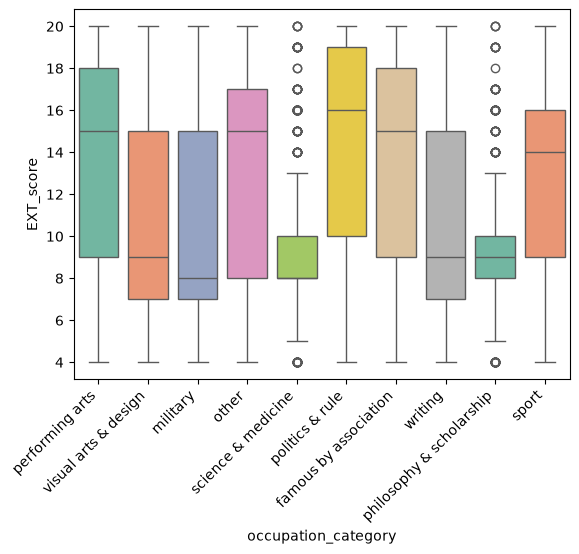

In [397]:
sns.boxplot(data=train, x='occupation_category', y='EXT_score', hue='occupation_category', palette='Set2', legend=False)
plt.xticks(rotation=45, ha='right') #roterer navnene på x aksen sånn at de ikke overlapper
plt.show()

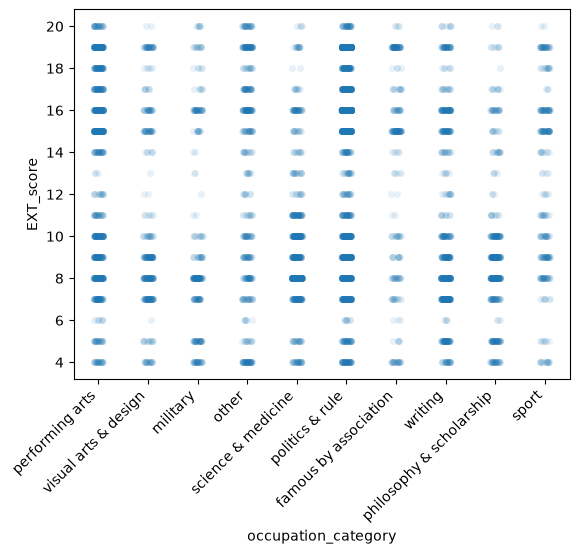

In [398]:
sns.stripplot(data=train, x='occupation_category', y='EXT_score', alpha=0.1, jitter=True)
plt.xticks(rotation=45, ha='right')
plt.show()

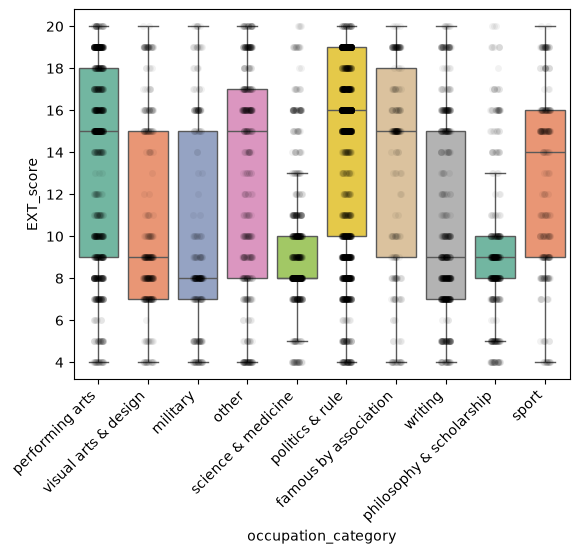

In [399]:
sns.boxplot(data=train, x='occupation_category', y='EXT_score', showfliers=False, hue='occupation_category', palette='Set2', legend=False)
sns.stripplot(data=train, x='occupation_category', y='EXT_score', color='black', alpha=0.05, jitter=True)
plt.xticks(rotation=45, ha='right')
plt.show()

Grafene viser at modellen lener seg på stereotyper av jobber, den tror for eksempel politics og rule og performing arts er mest ekstrovert. Den mener også at science og medicine og philosophy og scolarship er minst ekstrovert

- Sjekker nevrotisisme utifra jobbtype

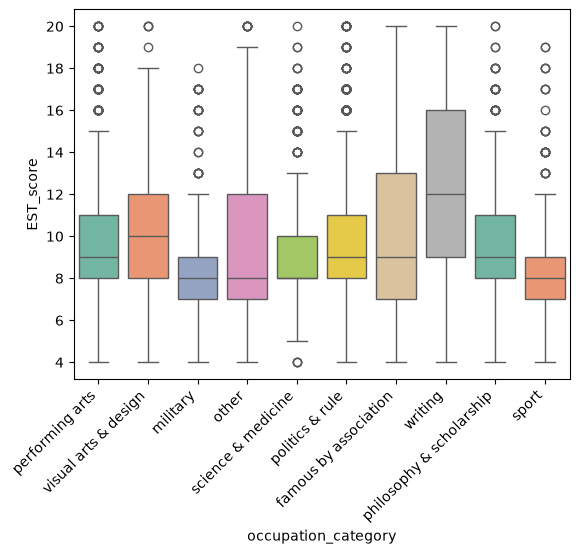

In [400]:
sns.boxplot(data=train, x='occupation_category', y='EST_score', hue='occupation_category', palette='Set2', legend=False)
plt.xticks(rotation=45, ha='right') #roterer navnene på x aksen sånn at de ikke overlapper
plt.show()

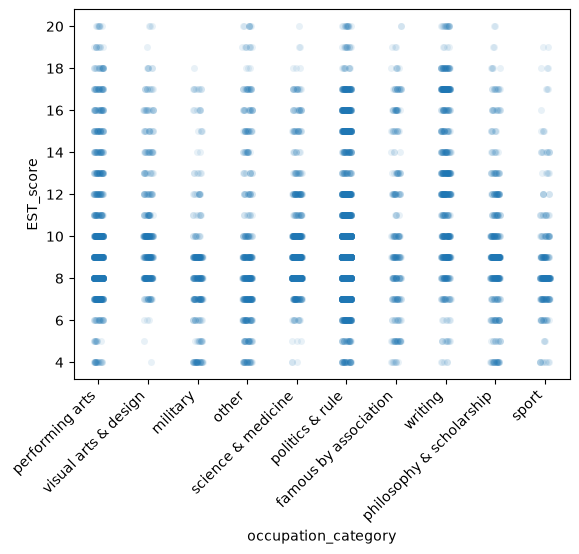

In [401]:
sns.stripplot(data=train, x='occupation_category', y='EST_score', alpha=0.1, jitter=True)
plt.xticks(rotation=45, ha='right')
plt.show()

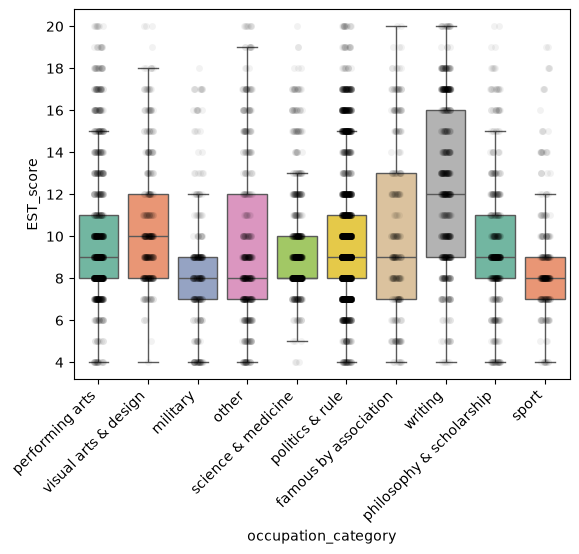

In [402]:
sns.boxplot(data=train, x='occupation_category', y='EST_score', showfliers=False, hue='occupation_category', palette='Set2', legend=False)
sns.stripplot(data=train, x='occupation_category', y='EST_score', color='black', alpha=0.05, jitter=True)
plt.xticks(rotation=45, ha='right')
plt.show()

Her lener modellen igjen på stereotyper der writing er den høyeste kategorien. Her er det military og sport som scorer lavest, dette mener jeg lener igjen på stereotypene til den følelsesløse soldaten eller en typisk sportspiller en "jock". Mer generelt så ser jeg at modellen er litt lent mot en lavere score 

- Sjekker omgjengelighet utifra jobbtype

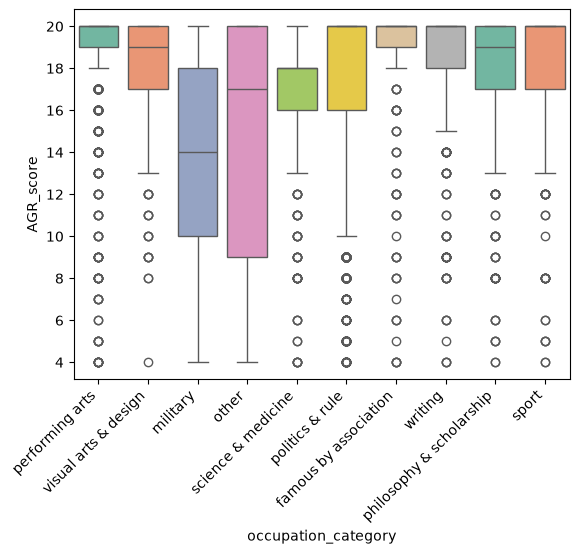

In [403]:
sns.boxplot(data=train, x='occupation_category', y='AGR_score', hue='occupation_category', palette='Set2', legend=False)
plt.xticks(rotation=45, ha='right') #roterer navnene på x aksen sånn at de ikke overlapper
plt.show()

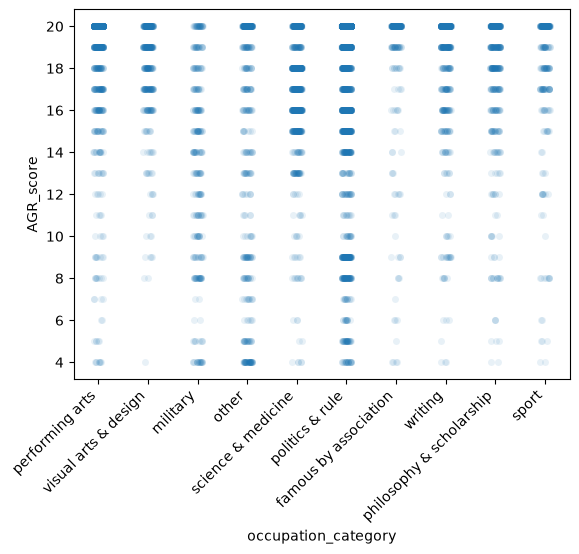

In [404]:
sns.stripplot(data=train, x='occupation_category', y='AGR_score', alpha=0.1, jitter=True)
plt.xticks(rotation=45, ha='right')
plt.show()

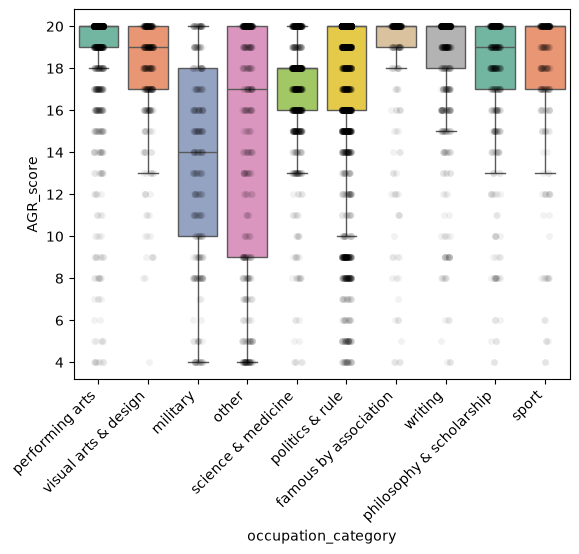

In [405]:
sns.boxplot(data=train, x='occupation_category', y='AGR_score', showfliers=False, hue='occupation_category', palette='Set2', legend=False)
sns.stripplot(data=train, x='occupation_category', y='AGR_score', color='black', alpha=0.05, jitter=True)
plt.xticks(rotation=45, ha='right')
plt.show()

Her er det et klart skifte, de fleste yrkene lener seg mot en veldig høy score i omgjengeliget. Det er en ganske stor spredning i military og other med noen som har veldig lav score, men generelt har alle en høy score.

- Sjekker planmessighet utifra jobbtype

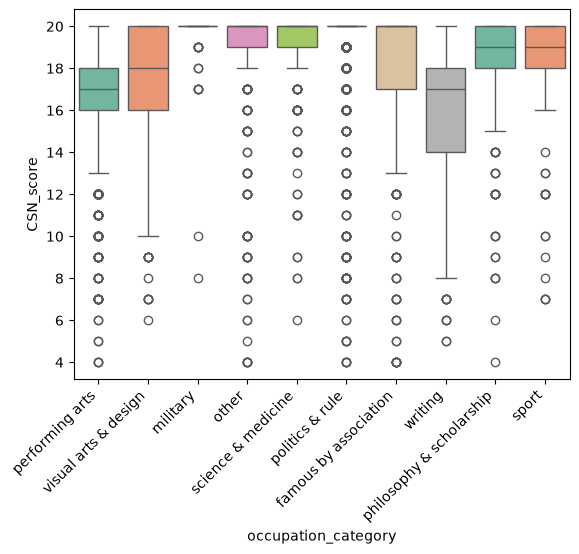

In [406]:
sns.boxplot(data=train, x='occupation_category', y='CSN_score', hue='occupation_category', palette='Set2', legend=False)
plt.xticks(rotation=45, ha='right') #roterer navnene på x aksen sånn at de ikke overlapper
plt.show()

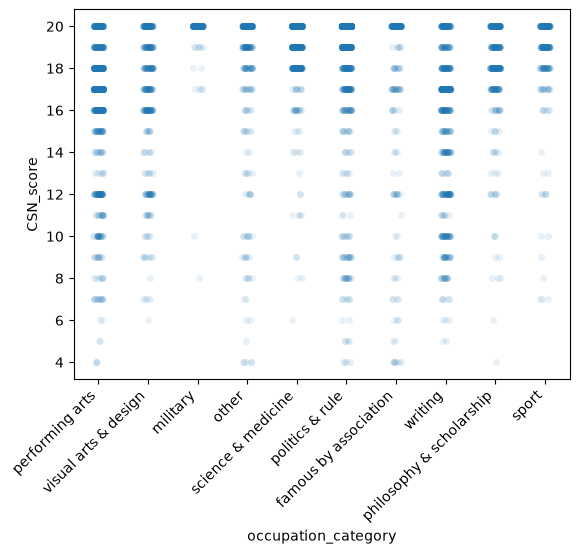

In [407]:
sns.stripplot(data=train, x='occupation_category', y='CSN_score', alpha=0.1, jitter=True)
plt.xticks(rotation=45, ha='right')
plt.show()

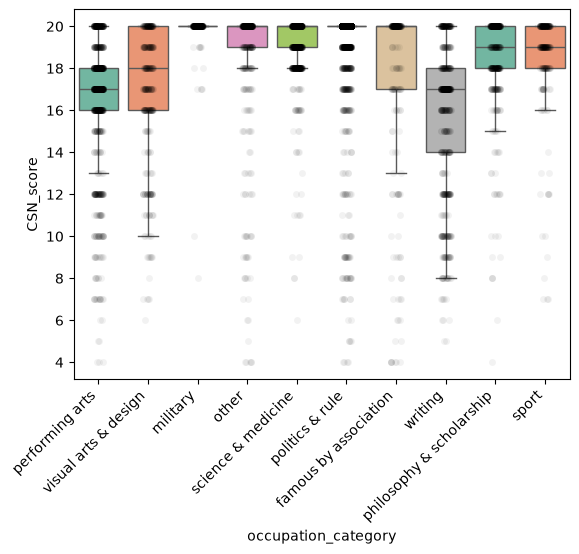

In [408]:
sns.boxplot(data=train, x='occupation_category', y='CSN_score', showfliers=False, hue='occupation_category', palette='Set2', legend=False)
sns.stripplot(data=train, x='occupation_category', y='CSN_score', color='black', alpha=0.05, jitter=True)
plt.xticks(rotation=45, ha='right')
plt.show()

Her lener modellen også en veldig høy score i planmessighet, men den bruker noen stereotyper, millitary har nesten bare toppscore og politikk og rule har også en veldig høy score. Writing har litt lavere score men der også er medianen på rundt 17 som er veldig høyt.

- Sjekker åpenhet mot jobbtype

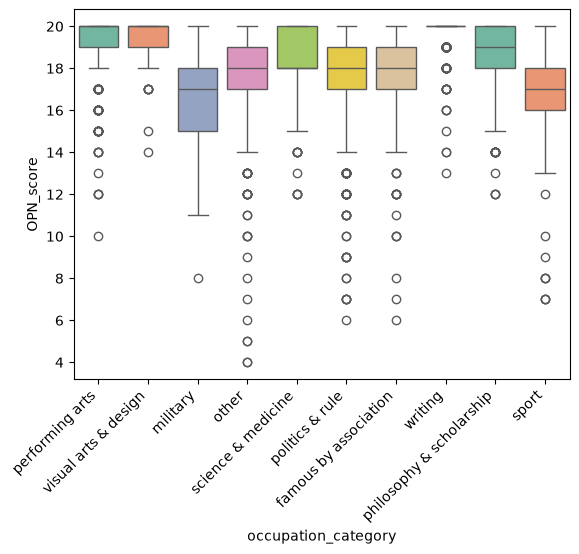

In [409]:
sns.boxplot(data=train, x='occupation_category', y='OPN_score', hue='occupation_category', palette='Set2', legend=False)
plt.xticks(rotation=45, ha='right') #roterer navnene på x aksen sånn at de ikke overlapper
plt.show()

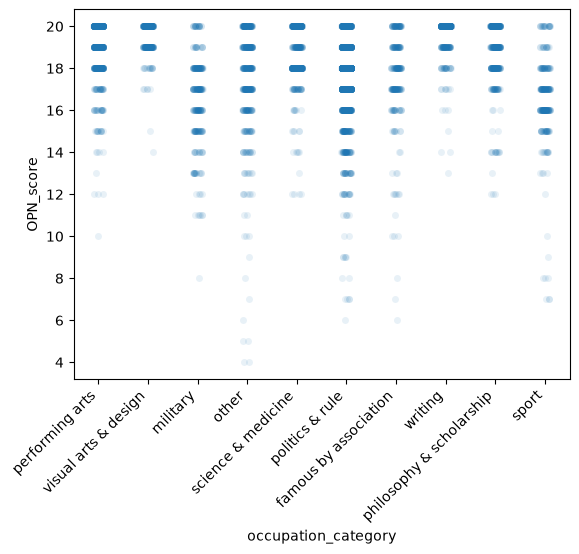

In [410]:
sns.stripplot(data=train, x='occupation_category', y='OPN_score', alpha=0.1, jitter=True)
plt.xticks(rotation=45, ha='right')
plt.show()

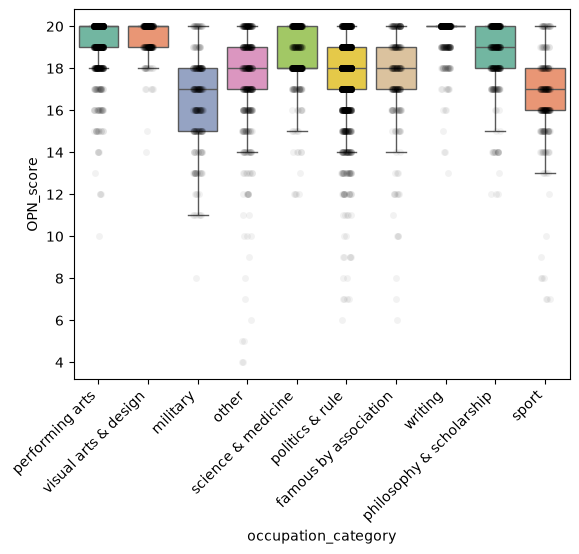

In [411]:
sns.boxplot(data=train, x='occupation_category', y='OPN_score', showfliers=False, hue='occupation_category', palette='Set2', legend=False)
sns.stripplot(data=train, x='occupation_category', y='OPN_score', color='black', alpha=0.05, jitter=True)
plt.xticks(rotation=45, ha='right')
plt.show()

Her er det også generelt høy score. Witing er mest åpen som igjen lener på en stereotyper, og millitary er litt mer tilbakeholden enn de andre men har fremdeles generelt en veldig høy score.

#### Politisk retning mot jobbtyper

- politisk økonomisk retning utifra jobbtyper

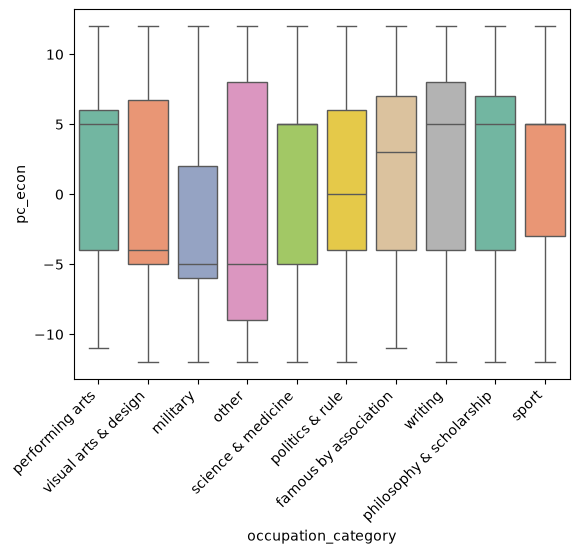

In [412]:
sns.boxplot(data=train, x='occupation_category', y='pc_econ', hue='occupation_category', palette='Set2', legend=False)
plt.xticks(rotation=45, ha='right') #roterer navnene på x aksen sånn at de ikke overlapper
plt.show()

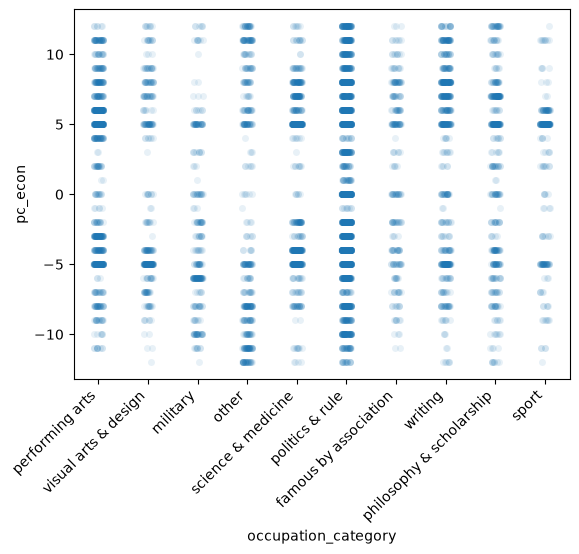

In [413]:
sns.stripplot(data=train, x='occupation_category', y='pc_econ', alpha=0.1, jitter=True)
plt.xticks(rotation=45, ha='right')
plt.show()

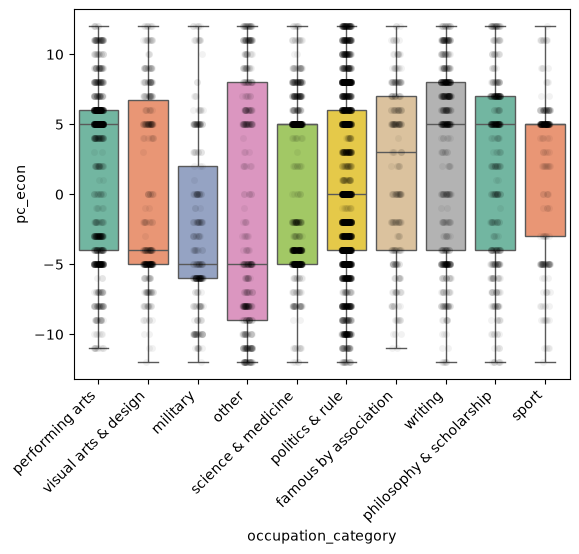

In [414]:
sns.boxplot(data=train, x='occupation_category', y='pc_econ', showfliers=False, hue='occupation_category', palette='Set2', legend=False)
sns.stripplot(data=train, x='occupation_category', y='pc_econ', color='black', alpha=0.05, jitter=True)
plt.xticks(rotation=45, ha='right')
plt.show()

Her er resultatene mer spredt, noe som tyder på at modellen ikke har like sterke antagelser på hvor hver person lener. Den har fremdeles noen stereotyper her, for eksempel at military lener mer mot høyre og at writing, performing arts og philosophy og scolarship lener mer mot venstre.

- politisk retning mot jobbtype

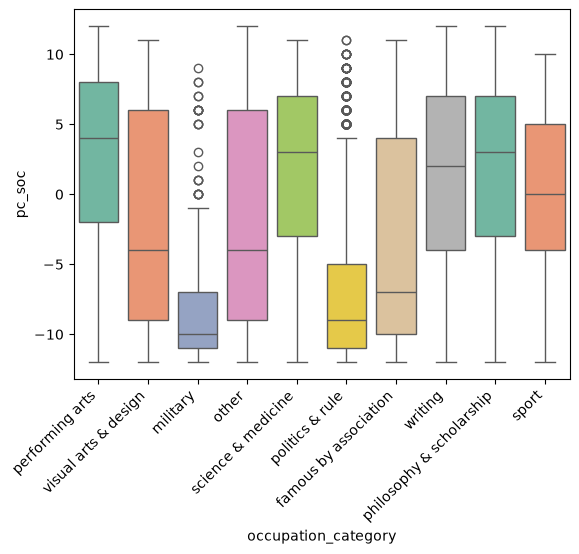

In [415]:
sns.boxplot(data=train, x='occupation_category', y='pc_soc', hue='occupation_category', palette='Set2', legend=False)
plt.xticks(rotation=45, ha='right') #roterer navnene på x aksen sånn at de ikke overlapper
plt.show()

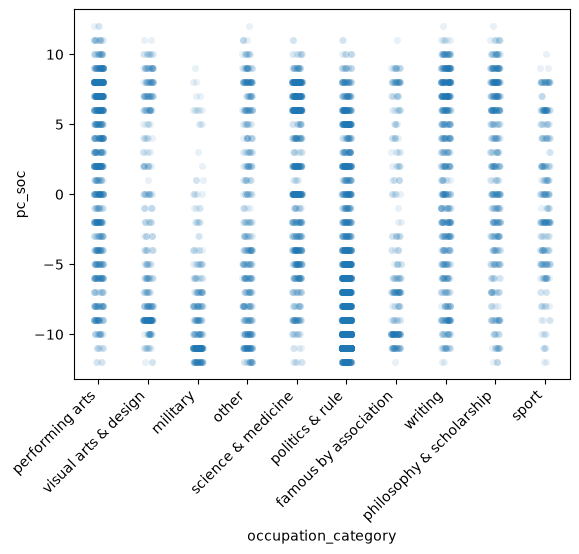

In [416]:
sns.stripplot(data=train, x='occupation_category', y='pc_soc', alpha=0.1, jitter=True)
plt.xticks(rotation=45, ha='right')
plt.show()

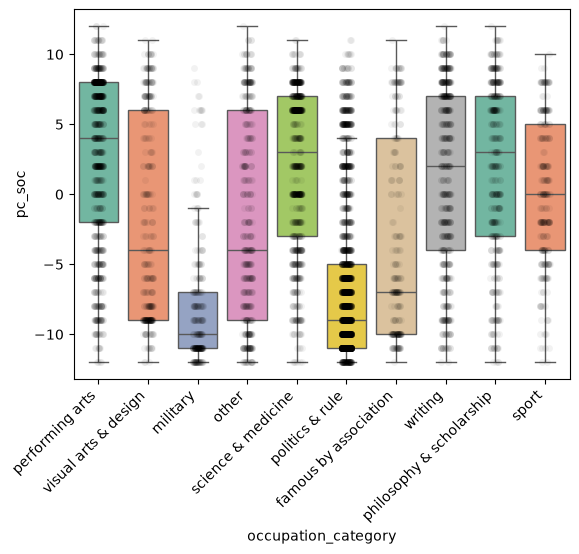

In [417]:
sns.boxplot(data=train, x='occupation_category', y='pc_soc', showfliers=False, hue='occupation_category', palette='Set2', legend=False)
sns.stripplot(data=train, x='occupation_category', y='pc_soc', color='black', alpha=0.05, jitter=True)
plt.xticks(rotation=45, ha='right')
plt.show()

Her følger modellen også de samme stereotypene, military og politics og rule er mer autoritær, mens det er mer spredning i de andre kategoriene. Det er interesant at selv de kategoriene som lener seg mot liberal siden er ikke like tydelig som de som er klart autoritær, noe som kan tyde på at modellen enten er litt usikker eller lener seg selv litt mot autoritæritet.

## Favoritt dyr

In [426]:
# Renser teksten litt (små bokstaver, fjerner mellomrom, fjerner "the")
train['animal_clean'] = train['personal.favorite_animal'].str.strip().str.lower().str.replace(r'^the\s+', '', regex=True)

# Finner de mest populære dyrene 
top_animals = train['animal_clean'].value_counts().head(10).index

# Filtrerer til kun disse dyrene
animal_subset = train[train['animal_clean'].isin(top_animals)]

# Krysstabell: jobbtype x dyr
crosstab = pd.crosstab(animal_subset['occupation_category'], animal_subset['animal_clean'])

In [427]:
def top_words(series, n=20):
    words = re.findall(r'\w+', ' '.join(series.dropna()).lower())
    return Counter(words).most_common(n)

- Funkjson som finner de 20 mest populære ordene filtrert for favoritt dyr 

In [428]:
top_words(train['animal_clean'])

[('falcon', 1389),
 ('wolf', 1172),
 ('eagle', 762),
 ('horse', 637),
 ('lion', 590),
 ('swan', 308),
 ('owl', 254),
 ('greyhound', 157),
 ('tiger', 151),
 ('dog', 140),
 ('a', 135),
 ('crane', 121),
 ('raven', 112),
 ('grey', 90),
 ('elephant', 78),
 ('cat', 64),
 ('leopard', 58),
 ('bear', 52),
 ('dragon', 43),
 ('peacock', 43)]

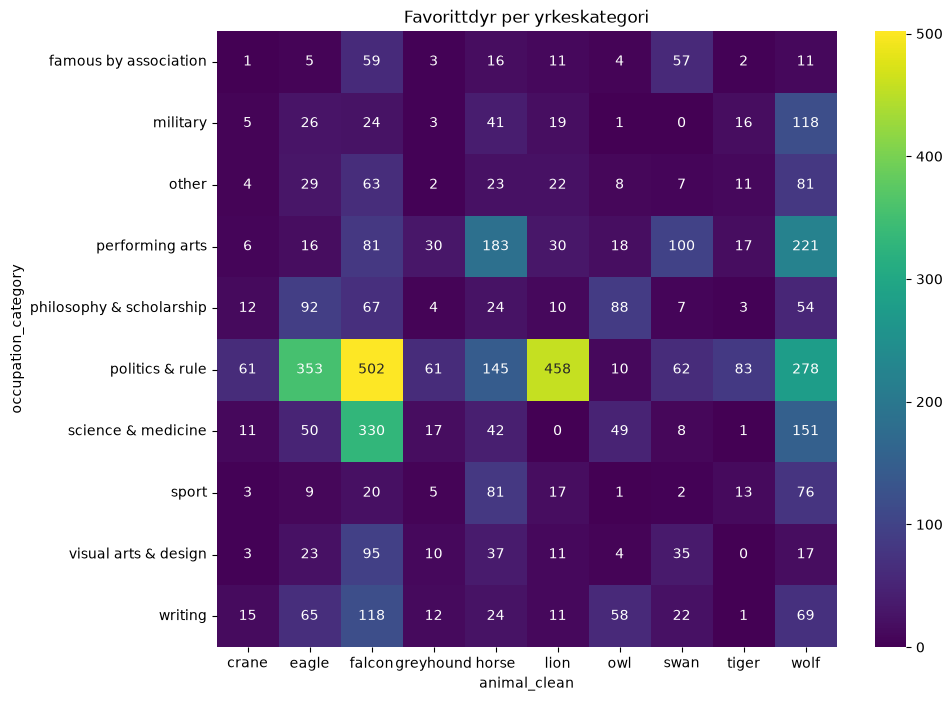

In [429]:
plt.figure(figsize=(10,8))
sns.heatmap(crosstab, annot=True, fmt='d', cmap='viridis')
plt.title('Favorittdyr per yrkeskategori')
plt.show()

In [430]:
train['occupation_category'].value_counts().head(20)

occupation_category
politics & rule             2479
performing arts              980
science & medicine           837
writing                      608
philosophy & scholarship     453
other                        446
visual arts & design         350
military                     288
sport                        272
famous by association        261
Name: count, dtype: int64

- Det er en klar skjevhet i dataene til occupation_category som gjør at de top dyrene nesten alle kommer fra politcs og rule fordi de er klart flest i den kategorien

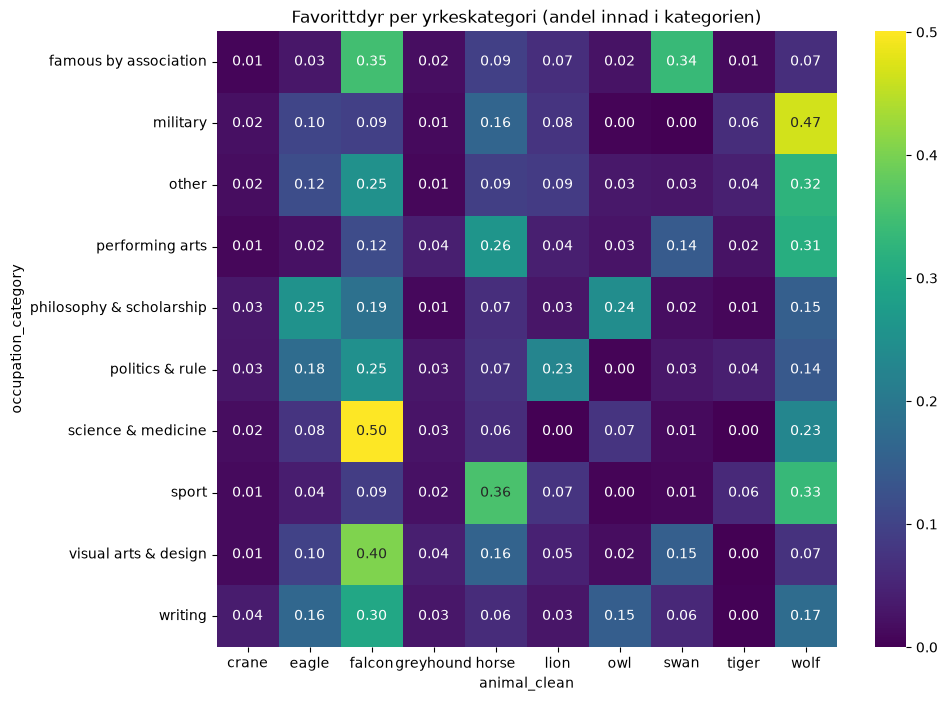

In [431]:
# Normaliserer per yrkeskategori (rad) sånn at hver rad summerer til 1
crosstab_pct = crosstab.div(crosstab.sum(axis=1), axis=0)

plt.figure(figsize=(10,8))
sns.heatmap(crosstab_pct, annot=True, fmt='.2f', cmap='viridis')
plt.title('Favorittdyr per yrkeskategori (andel innad i kategorien)')
plt.show()

I det normaliserte heatmapet så ser man mer tydelig at falcon er det mest valgte dyret. 50% i science og medicine noe som kanskje er en stereotyper modellen har om at science og medicine folk er fokuserte eller har et "falkesyn". Falcon er også størst andel i visual art og design, writing, other og politics and rule. Falcon som favorittdyr til politikere og ledere gir mening, det er et rovdyr eller har symbolikk som overlapper med måter ledere vil bli sett på. Det som jeg er litt mer usikker på er hvorfor den har valgt falcon som favorittdyr på writing og visual art og design. Jeg ser ingen åpenbare stereotyper her som gjør at jeg begynner å tenke om at falcon som favorittdyr er en bias eller en standard som modellen har siden det er så stor prosent av settet. Jeg føler at det er størst andel av other som har falcon som favorittdyr og det er også pekende på dette. Ellers føler jeg at de andre dyrene passer ganske bra til de forventede stereotypene. Philosophy og scolarship har både owl og eagle som gir mening. Wolf er spredt ganske jevnt utover med flest i military og sport, noe som jeg mener også gir mening utifra setrotyper

## Tidstrender

- Ser på år personene født utifra den politiske scoren

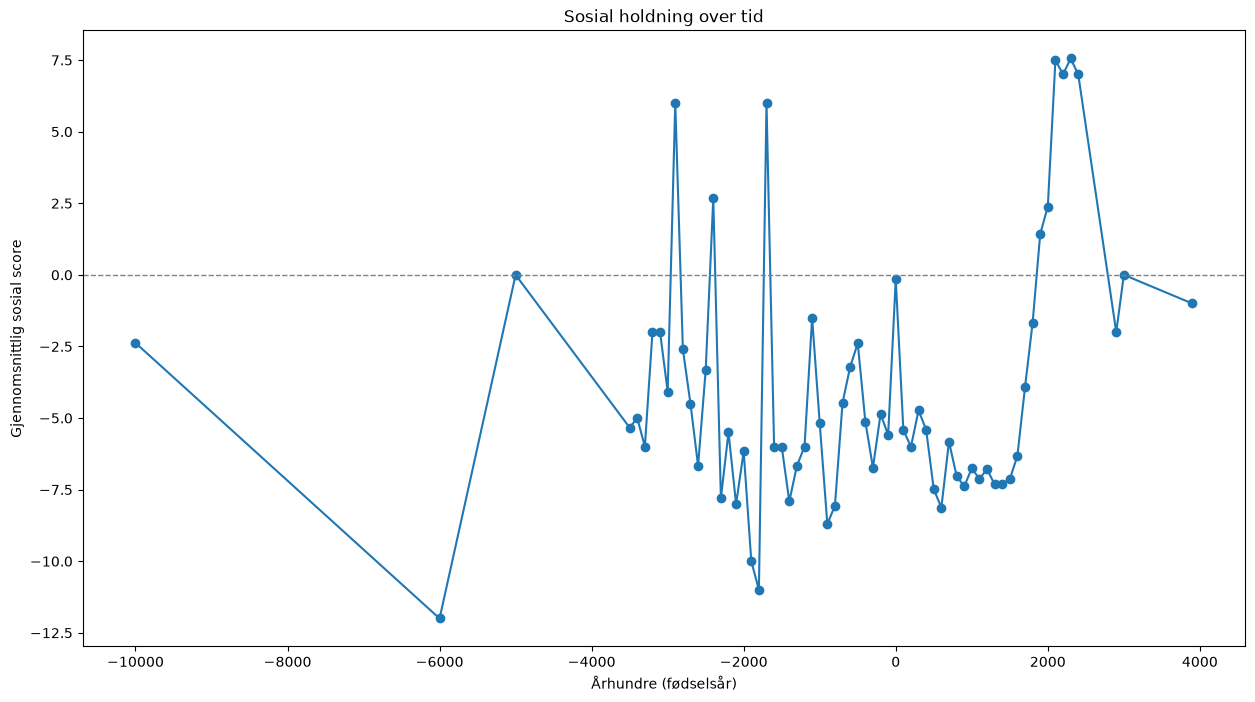

In [424]:
train['century'] = (train['born'] // 100) * 100

trend = train.groupby('century')['pc_soc'].mean()

trend.plot(marker='o', figsize=(15,8))
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.xlabel('Århundre (fødselsår)')
plt.ylabel('Gjennomsnittlig sosial score')
plt.title('Sosial holdning over tid')
plt.show()

Grafen viser at sosial holdning svinger kraftig gjennom historien, spesielt i de eldste periodene. Fra -10 000 til -2000 hopper kurven mye opp og ned, men jeg tror ikke dette er et reelt mønster. Det er sannsynligvis bare veldig få personer født i disse periodene, så gjennomsnittet blir styrt av en eller to enkeltpersoner.

Fra rundt -1500 til år 0 flater kurven mer ut, men ligger stabilt under null. Det gir mening. Modellen gir antikkens personer en mer autoritær holdning, som stemmer med at man ikke forventer at f.eks. en romer skal ha moderne liberale syn på ting som kjønn eller innvandring.

Det mest interessante funnet er det store skiftet som starter rundt år 1700 til 1800: kurven stiger jevnt fra autoritær til liberal og flater ut på et høyt platå rundt år 2000 til 2500. Dette tror jeg viser at modellen kobler sosial holdning direkte til fødselsår og projiserer moderne, liberale verdier på personer født nærmere vår tid. Altså en tydelig anakronisme, siden dette sier mer om hva modellen forventer av "noen født nylig" enn om personen faktisk hadde de holdningene.

Mot slutten (etter ca. 2500) faller kurven brått igjen. Dette er nok fiktive personer som modellen har anslått som mer autoritære enn nåtidens mennesker. Det kan også være at det er veldig få som er i det tidsrommet som gjør at gjennomsnittet blir veldig vektet på dem slik som de som er født i årene -2000 og nedover.


- Ser på årtusenet personene født utifra den politisk økonomiske scoren

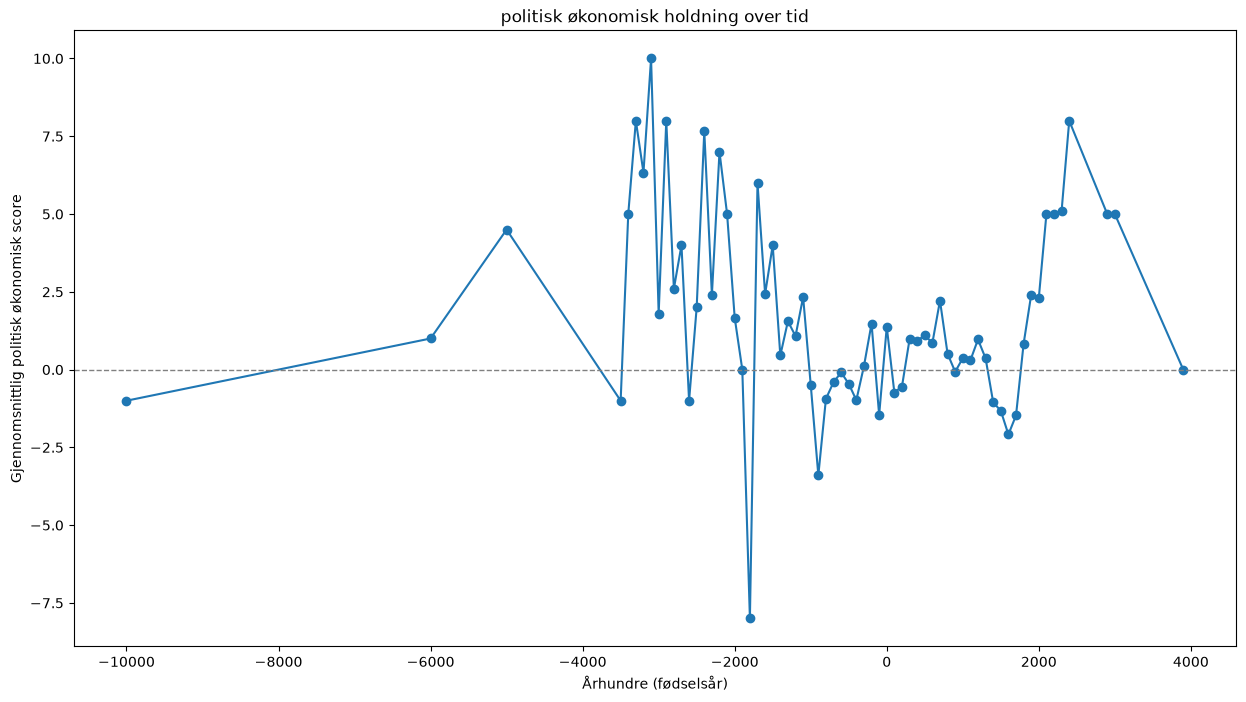

In [440]:
train['century'] = (train['born'] // 100) * 100

trend = train.groupby('century')['pc_econ'].mean()

trend.plot(marker='o', figsize=(15,8))
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.xlabel('Århundre (fødselsår)')
plt.ylabel('Gjennomsnittlig politisk økonomisk score')
plt.title('politisk økonomisk holdning over tid')
plt.show()

Grafen svinger mye gjennom hele tidslinjen, uten et like tydelig og jevnt skifte som vi så for sosial holdning. Fra -10 000 til -6000 ligger kurven nær null, men med veldig få personer bak hvert punkt er dette usikkert. Fra -3500 til -1500 er det store hopp opp og ned mellom -1 og 10, inkludert et kraftig bunnpunkt ned mot -8 rundt -1800. Dette tyder på lite data og enkeltpersoner som drar gjennomsnittet i ulike retninger, ikke et stabilt mønster.

Fra rundt -1000 og fram til år 0 flater kurven mer ut og ligger stort sett rundt 0, med noe variasjon mellom -1,5 og 1,5. Fra år 0 og utover er det en svak, ujevn stigning fram mot en topp rundt år 2500 (opp mot 8), før kurven faller tilbake mot 0 igjen nær år 4000.

Sammenlignet med sosial holdning er mønsteret her mye svakere og mindre konsistent. Det tyder på at modellen ikke kobler økonomisk holdning like sterkt til fødselsår som den gjør med sosial holdning. Det gir en viss mening: begreper som "venstre/høyre i økonomisk politikk" er mer knyttet til spesifikke politiske og økonomiske systemer som gjør at modellen har noe mer konkret å feste stereotypene og biasene sine på.
